##  __1- Dataset Preparation__ 

## 1.1 Resizing DataSet to Speed Up the Training

 <span style="color: red;"> DO NOT RUN IT!!!!</span>

In [ ]:
import os
from PIL import Image

original_path = r"D:\Downloadf\archive\leapGestRecog"
resized_path = r"D:\Downloadf\leapGestRecog_resized"

target_size = (224, 224)

for root, dirs, files in os.walk(original_path):
    
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            
            original_img_path = os.path.join(root, file)
            
            # إنشاء نفس الهيكل داخل مجلد جديد
            relative_path = os.path.relpath(root, original_path)
            new_folder = os.path.join(resized_path, relative_path)
            os.makedirs(new_folder, exist_ok=True)
            
            new_img_path = os.path.join(new_folder, file)
            
            # فتح الصورة وتصغيرها
            img = Image.open(original_img_path)
            img = img.resize(target_size, Image.LANCZOS)
            
            # حفظ بجودة عالية
            img.save(new_img_path, quality=90)
            



## 1.2 Explore Dataset and Choose Gestures

In [2]:
import os
import pandas as pd

dataset_path = r"D:\Downloadf\leapGestRecog_resized"

relevant_gestures = {
    "01_palm": "Palm",
    "03_fist": "Fist"
}

data = []

for subject in os.listdir(dataset_path):
    subject_path = os.path.join(dataset_path, subject)

    if os.path.isdir(subject_path):

        for gesture_folder in os.listdir(subject_path):

            if gesture_folder in relevant_gestures:
                gesture_path = os.path.join(subject_path, gesture_folder)

                # يدخل داخل كل الملفات حتى لو في مجلد right
                for root, dirs, files in os.walk(gesture_path):
                    for file in files:
                        if file.endswith(('.png', '.jpg', '.jpeg')):
                            img_path = os.path.join(root, file)

                            data.append({
                                "image_path": img_path,
                                "label": relevant_gestures[gesture_folder]
                            })

df = pd.DataFrame(data) # to print first 5 raws
print(df.head())
print("Total number for each gesture:")
print(df["label"].value_counts()) # count how many image in each label


                                          image_path label
0  D:\Downloadf\leapGestRecog_resized\00\01_palm\...  Palm
1  D:\Downloadf\leapGestRecog_resized\00\01_palm\...  Palm
2  D:\Downloadf\leapGestRecog_resized\00\01_palm\...  Palm
3  D:\Downloadf\leapGestRecog_resized\00\01_palm\...  Palm
4  D:\Downloadf\leapGestRecog_resized\00\01_palm\...  Palm
Total number for each gesture:
label
Palm    4000
Fist    4000
Name: count, dtype: int64


## 1.3 Visualize Dataset

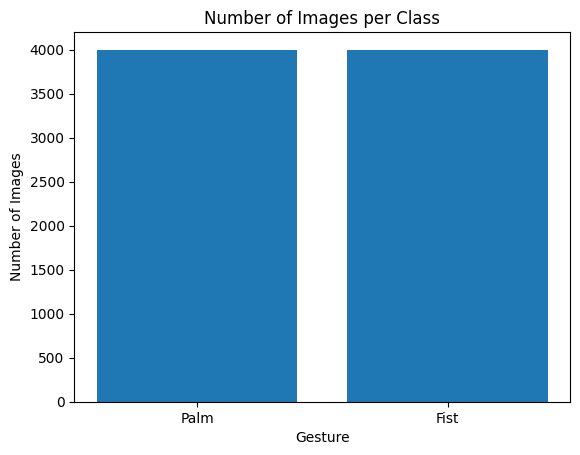

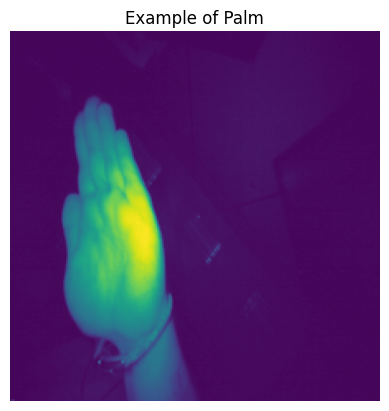

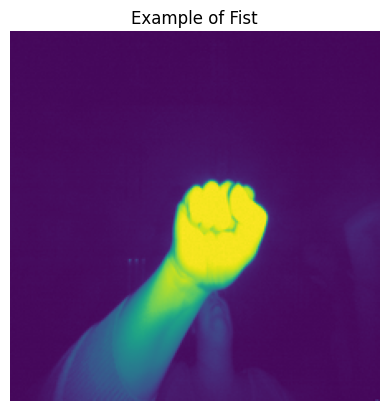

In [3]:
import matplotlib.pyplot as plt
from PIL import Image
import random

class_counts = df["label"].value_counts()

plt.figure()
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Gesture")
plt.ylabel("Number of Images")
plt.title("Number of Images per Class")
plt.show()

for label in df["label"].unique():
    
    sample_path = random.choice(df[df["label"] == label]["image_path"].values)
    
    img = Image.open(sample_path)
    
    plt.figure()
    plt.imshow(img)
    plt.title(f"Example of {label}")
    plt.axis("off")
    plt.show()


## 1.4 Data Split (70% training - 30% validation & testing)

In [4]:
from sklearn.model_selection import train_test_split

# أول تقسيم: Train (70%) و Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# ثاني تقسيم: Validation (15%) و Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
print("\nTrain distribution:")
print(train_df["label"].value_counts())

print("\nValidation distribution:")
print(val_df["label"].value_counts())

print("\nTest distribution:")
print(test_df["label"].value_counts())


Train size: 5600
Validation size: 1200
Test size: 1200

Train distribution:
label
Palm    2800
Fist    2800
Name: count, dtype: int64

Validation distribution:
label
Palm    600
Fist    600
Name: count, dtype: int64

Test distribution:
label
Palm    600
Fist    600
Name: count, dtype: int64
